In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [5]:
df["seismic_event_detected"].unique()

array([0, 1])

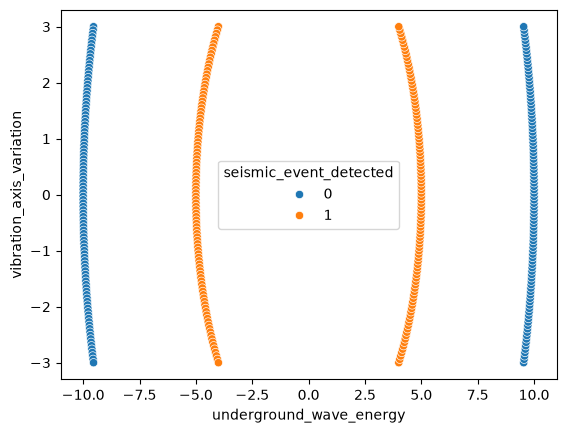

In [6]:
sns.scatterplot(x=df["underground_wave_energy"],y=df["vibration_axis_variation"],hue = df["seismic_event_detected"])
plt.show()

In [7]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [8]:
X

array([[ 9.53939201, -3.        ],
       [ 9.55824059, -2.93939394],
       [ 9.57666854, -2.87878788],
       [ 9.59467828, -2.81818182],
       [ 9.61227215, -2.75757576],
       [ 9.62945245, -2.6969697 ],
       [ 9.64622137, -2.63636364],
       [ 9.66258107, -2.57575758],
       [ 9.67853361, -2.51515152],
       [ 9.69408101, -2.45454545],
       [ 9.70922521, -2.39393939],
       [ 9.7239681 , -2.33333333],
       [ 9.73831149, -2.27272727],
       [ 9.75225716, -2.21212121],
       [ 9.76580681, -2.15151515],
       [ 9.77896207, -2.09090909],
       [ 9.79172455, -2.03030303],
       [ 9.80409577, -1.96969697],
       [ 9.81607722, -1.90909091],
       [ 9.82767031, -1.84848485],
       [ 9.83887643, -1.78787879],
       [ 9.8496969 , -1.72727273],
       [ 9.86013297, -1.66666667],
       [ 9.87018588, -1.60606061],
       [ 9.87985679, -1.54545455],
       [ 9.88914683, -1.48484848],
       [ 9.89805706, -1.42424242],
       [ 9.90658851, -1.36363636],
       [ 9.91474216,

In [9]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(320, 80, 320, 80)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [15]:
X_train.ndim

2

In [16]:
y_train.ndim

2

In [17]:
from torch import nn

In [18]:
class NonLinear(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2,out_features=10)
        self.layer2 = nn.Linear(in_features=10,out_features=10)
        self.layer3 = nn.Linear(in_features=10,out_features=1)

        self.relu = nn.ReLU()

    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

In [19]:
model = NonLinear()

In [20]:
loss_fn = nn.BCEWithLogitsLoss()

In [21]:
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [22]:
def calculate_accuracy(y_test,y_pred):
    correct = torch.eq(y_test,y_pred).sum().item()
    accuracy = (correct / len(y_pred))*100
    return accuracy

In [23]:
y_logits = model(X_test)[:10]

In [24]:
y_logits

tensor([[-0.6337],
        [-0.0678],
        [-0.2782],
        [-0.6235],
        [ 0.1135],
        [ 0.1068],
        [-0.2592],
        [ 0.1141],
        [-0.1064],
        [-0.1658]], grad_fn=<SliceBackward0>)

In [25]:
y_pred_probs = torch.sigmoid(y_logits)

In [26]:
y_pred_probs

tensor([[0.3467],
        [0.4831],
        [0.4309],
        [0.3490],
        [0.5283],
        [0.5267],
        [0.4356],
        [0.5285],
        [0.4734],
        [0.4586]], grad_fn=<SigmoidBackward0>)

In [27]:
y_preds = torch.round(y_pred_probs)

In [28]:
y_preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

In [29]:
y_test[:10]

tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [30]:
calculate_accuracy(y_test[:10],y_preds)

20.0

In [31]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_test = y_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc = calculate_accuracy(y_test = y_test, y_pred= test_pred)

        if epoch % 100==0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

Epoch: 0, Loss: 0.7377288937568665, Accuracy: 41.5625, Test Loss: 0.7307690978050232, Test Acc: 42.5
Epoch: 100, Loss: 0.680770754814148, Accuracy: 48.75, Test Loss: 0.6565325856208801, Test Acc: 55.00000000000001
Epoch: 200, Loss: 0.6432825326919556, Accuracy: 48.75, Test Loss: 0.6218035817146301, Test Acc: 55.00000000000001
Epoch: 300, Loss: 0.6048239469528198, Accuracy: 48.75, Test Loss: 0.5857869982719421, Test Acc: 55.00000000000001
Epoch: 400, Loss: 0.5660477876663208, Accuracy: 51.24999999999999, Test Loss: 0.5493413209915161, Test Acc: 55.00000000000001
Epoch: 500, Loss: 0.5243783593177795, Accuracy: 61.5625, Test Loss: 0.5094696283340454, Test Acc: 57.49999999999999
Epoch: 600, Loss: 0.4791448712348938, Accuracy: 75.0, Test Loss: 0.46497973799705505, Test Acc: 81.25
Epoch: 700, Loss: 0.4316975176334381, Accuracy: 92.5, Test Loss: 0.41685476899147034, Test Acc: 91.25
Epoch: 800, Loss: 0.38333356380462646, Accuracy: 98.125, Test Loss: 0.36752849817276, Test Acc: 98.75
Epoch: 900

In [32]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

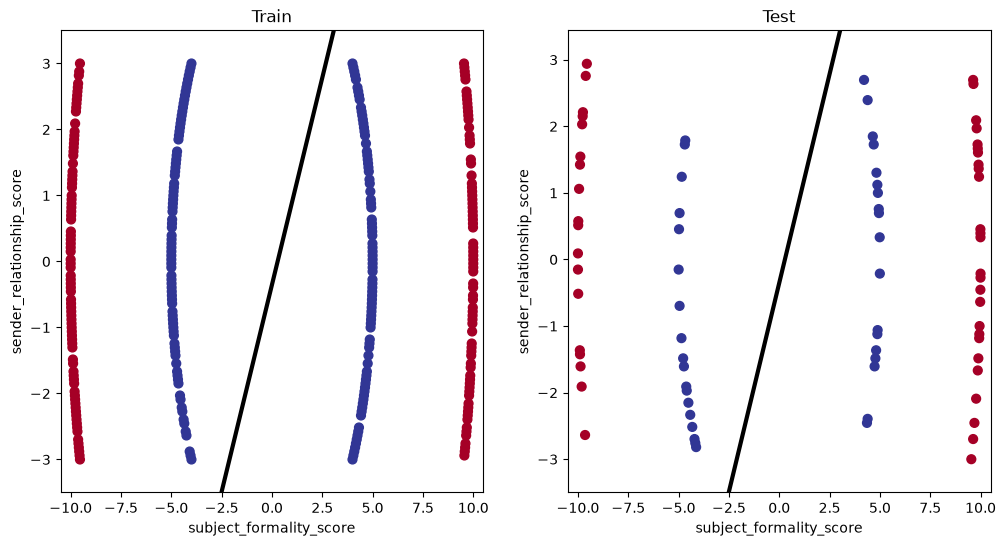

In [33]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model, X_test, y_test)

plt.show()

In [34]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([320, 2])
torch.Size([320, 1])
torch.Size([80, 2])
torch.Size([80, 1])


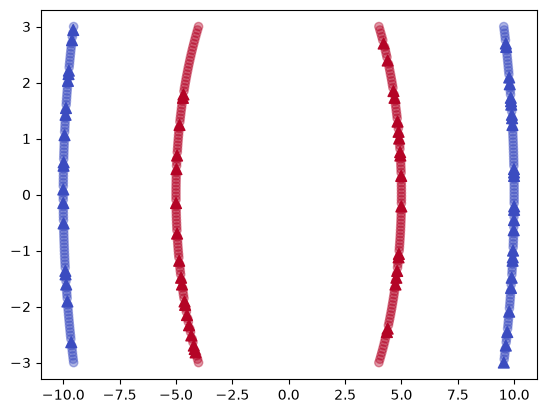

In [35]:
# Train
plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train.squeeze(),
    cmap="coolwarm",
    marker="o",
    alpha=0.4,
    label="Train"
)

# Test
plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=y_test.squeeze(),
    cmap="coolwarm",
    marker="^",
    s=60,
    label="Test"
)

wrong = (test_pred != y_test)

plt.scatter(
    X_test[wrong.squeeze(),0],
    X_test[wrong.squeeze(),1],
    facecolors="none",
    edgecolors="black",
    s=150,
    linewidth=2,
    label="Wrong Prediction"
)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [37]:
print(
    classification_report(
        y_test.numpy(),
        test_pred.numpy()
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        44
         1.0       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [38]:
cm = confusion_matrix(y_test.numpy(), test_pred.numpy())

print(cm)

[[44  0]
 [ 0 36]]


In [39]:
probabilities = torch.sigmoid(test_logits)

In [40]:
probabilities

tensor([[0.7647],
        [0.6580],
        [0.1597],
        [0.7565],
        [0.2220],
        [0.1844],
        [0.6493],
        [0.2266],
        [0.5677],
        [0.1062],
        [0.2374],
        [0.6124],
        [0.1417],
        [0.1560],
        [0.1045],
        [0.1393],
        [0.6446],
        [0.6912],
        [0.6412],
        [0.7386],
        [0.1617],
        [0.2143],
        [0.7472],
        [0.5989],
        [0.2776],
        [0.7547],
        [0.1277],
        [0.6723],
        [0.5580],
        [0.1725],
        [0.7532],
        [0.1702],
        [0.5559],
        [0.1425],
        [0.6362],
        [0.1207],
        [0.1314],
        [0.5982],
        [0.1047],
        [0.1033],
        [0.7200],
        [0.1410],
        [0.1605],
        [0.1815],
        [0.1771],
        [0.7259],
        [0.1033],
        [0.1346],
        [0.1906],
        [0.1162],
        [0.1356],
        [0.7142],
        [0.6123],
        [0.1538],
        [0.6800],
        [0

In [41]:
fpr, tpr, thresholds = roc_curve(
    y_test.numpy(),
    probabilities.numpy()
)

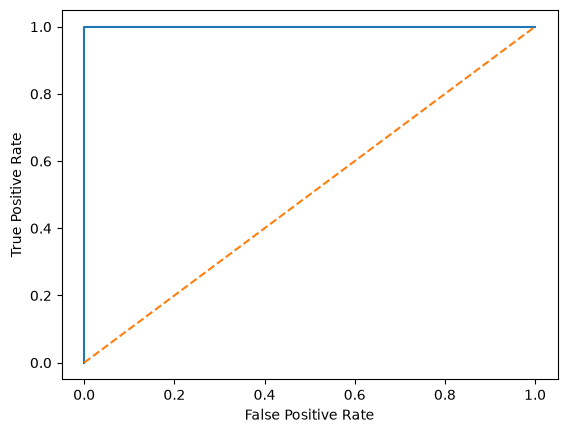

In [42]:
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [43]:
auc = roc_auc_score(
    y_test.numpy(),
    probabilities.numpy()
)

print(auc)

1.0


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_decision_boundary(model, X, y):
    # Modeli değerlendirme moduna al
    model.eval()

    # X ekseninin minimum ve maksimum değerleri
    x_min = X[:, 0].min().item() - 0.1
    x_max = X[:, 0].max().item() + 0.1

    # Y ekseninin minimum ve maksimum değerleri
    y_min = X[:, 1].min().item() - 0.1
    y_max = X[:, 1].max().item() + 0.1

    # Grafik alanını küçük karelere böl
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Karelerin koordinatlarını tek bir dizi haline getir
    X_to_pred = np.column_stack((xx.ravel(), yy.ravel()))

    # NumPy dizisini Tensor'a çevir
    X_to_pred = torch.from_numpy(X_to_pred).float()

    # Model tahmini
    with torch.inference_mode():
        y_logits = model(X_to_pred)
        y_pred = torch.round(torch.sigmoid(y_logits))

    # Tahminleri tekrar kare forma getir
    y_pred = y_pred.reshape(xx.shape)

    # Karar sınırını çiz
    plt.contourf(xx, yy, y_pred, alpha=0.3, cmap="coolwarm")

    # Gerçek verileri çiz
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y.squeeze(),
        cmap="coolwarm",
        edgecolors="black"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

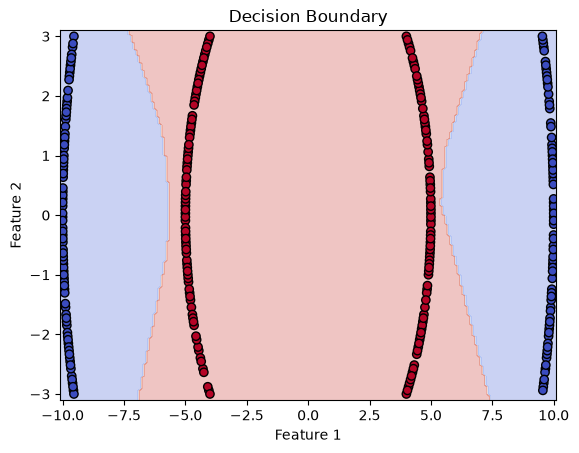

In [45]:
plot_decision_boundary(model, X_train, y_train)

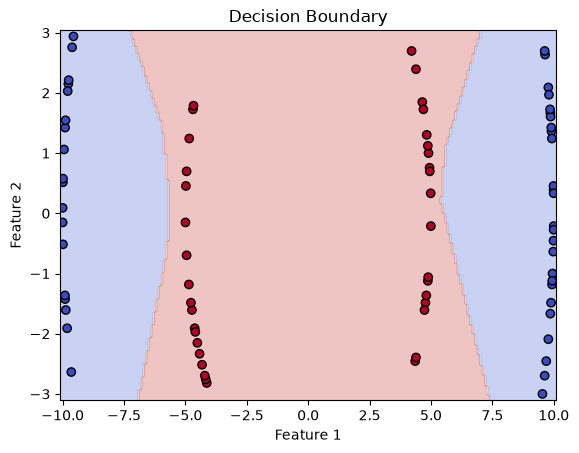

In [46]:
plot_decision_boundary(model, X_test, y_test)